# Machine Learning Backtesting Pipeline (TensorFlow & MLflow)
This notebook implements an Expanding Window Time-Series Split, Random Forest (with GridSearchCV), Deep Neural Network (TensorFlow/Keras + KerasTuner), and Decile Sorting Backtesting.
All model training and hyperparameter searches are tracked using MLflow.


In [1]:
import IPython.core.pylabtools
import os
import sys
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import mlflow
import keras_tuner as kt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# Ask TensorFlow to list all available physical GPUs
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"✅ M3 Pro GPU ACTIVATED! Found: {gpu_devices}")
    # Optional: Set memory growth to prevent TF from hoarding all unified memory
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("❌ GPU not found. TensorFlow is falling back to the CPU.")

✅ M3 Pro GPU ACTIVATED! Found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Setup & Data Loading (with MLflow)

In [2]:
# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Spark setup
from dotenv import load_dotenv
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '../../')))
sys.path.append(os.getcwd())

from src.common.setup_spark import create_spark_session
from config.config_spark import Paths

# MLflow Setup
mlflow.set_tracking_uri("sqlite:///mlflow.db") # Local SQLite database for tracking
experiment_name = "SP500_Momentum_Backtest"
mlflow.set_experiment(experiment_name)
print(f"MLflow Experiment set to: {experiment_name}")

spark = create_spark_session()
print("Spark Session created.")

# Load Data
df_gold = spark.read.format("delta").load(Paths.SP500_MOMENTUM_VALUE_PROFITABLE_WEEKLY_GOLD)
df_gold.createOrReplaceTempView("gold_prices")

df = df_gold.toPandas()

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.weekday

print(f"Data loaded: {df.shape}")
print(f"Years: {df['year'].unique().min()}")


2026-03-04 09:33:56.026 | INFO     | src.common.setup_spark:create_spark_session:19 - 🛠️ Configurant Spark avec le connecteur GCS : https://repo1.maven.org/maven2/com/google/cloud/bigdataoss/gcs-connector/hadoop3-2.2.6/gcs-connector-hadoop3-2.2.6-shaded.jar


MLflow Experiment set to: SP500_Momentum_Backtest


26/03/04 09:33:57 WARN Utils: Your hostname, MacBook-Pro-5.local resolves to a loopback address: 127.0.0.1; using 192.168.1.1 instead (on interface en0)
26/03/04 09:33:57 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /Users/forget/.ivy2/cache
The jars for the packages stored in: /Users/forget/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-804f9475-d5da-4ae3-bb39-db5a437cc2a5;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.2.1 in central


:: loading settings :: url = jar:file:/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found io.delta#delta-storage;3.2.1 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 99ms :: artifacts dl 4ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.2.1 from central in [default]
	io.delta#delta-storage;3.2.1 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   |   0   |   0   ||   3   |   0   |
	---------------------------------------------------------------------
:: retrieving :: org.apache.spark#spark-submit-parent-804f9475-d5da-4ae3-bb39-db5a437cc2a5
	confs: [default]
	0 artifacts copied, 3 already retrieved (0kB/2ms)
26/03/04 09:33:57 WARN NativeCodeLoader: Unable to load native-hadoo

Spark Session created.


Data loaded: (692800, 125)
Years: 1985


In [3]:
df.describe()

,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,mom1w,...,daysOfInventoryOutstanding,operatingCycle,cashConversionCycle,freeCashFlowToEquity,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,year,month,week
count,692800,692800.000000,6.928000e+05,692800.000000,692800.000000,692800.000000,692800.000000,692800.000000,692800.000000,692800.000000,...,6.928000e+05,6.928000e+05,6.928000e+05,6.928000e+05,6.928000e+05,6.928000e+05,6.928000e+05,692800.000000,692800.000000,692800.000000
mean,2010-09-12 21:18:35.418013952,67.421128,7.777453e+06,0.000427,0.000088,-0.001038,-0.001119,-0.000535,0.000394,-0.000177,...,1.197808e+02,2.015802e+02,2.601800e+00,-1.772471e+10,7.999667e+08,5.729299e+09,-3.443595e+10,2010.196172,6.561142,3.963318
min,1985-09-06 00:00:00,0.004101,2.000000e+00,-0.088068,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-6.767609e+04,-6.676884e+04,-6.085191e+05,-4.201628e+12,-2.851201e+13,-2.657730e+11,-4.229289e+12,1985.000000,1.000000,0.000000
25%,2003-02-21 00:00:00,11.980000,9.567228e+05,-0.004305,0.000004,-0.501075,-0.501155,-0.503106,-0.500000,-0.500975,...,0.000000e+00,5.086774e+01,3.324904e+00,-7.247000e+09,-7.107290e+06,0.000000e+00,-1.381200e+10,2003.000000,4.000000,4.000000
50%,2012-06-22 00:00:00,28.990000,2.195348e+06,0.000874,0.000063,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.256906e+01,9.420901e+01,4.351178e+01,-2.042000e+09,1.240798e+08,1.654000e+09,-3.420000e+09,2012.000000,7.000000,4.000000
75%,2019-08-31 18:00:00,66.760000,5.099041e+06,0.005707,0.000174,0.498956,0.500000,0.502304,0.500000,0.500000,...,7.704073e+01,1.478187e+02,9.424215e+01,-1.034160e+08,5.679884e+08,6.046500e+09,-9.173500e+07,2019.000000,10.000000,4.000000
max,2026-02-20 00:00:00,9924.400000,9.276606e+09,0.092871,0.000328,1.000000,1.000000,1.000000,1.000000,1.000000,...,3.646790e+06,3.646790e+06,3.646007e+06,4.842830e+11,2.853340e+13,3.229622e+12,3.164338e+13,2026.000000,12.000000,4.000000
std,NaN,191.216925,4.625319e+07,0.010900,0.000087,0.578117,0.579065,0.579858,0.578166,0.578542,...,1.580589e+04,1.599161e+04,1.655249e+04,1.548944e+11,3.140788e+11,2.870217e+10,3.680085e+11,10.679603,3.463799,0.208719


### Calculate Target Variable: 1-Month Ahead Expected Excess Return

In [4]:
def create_discrete_target(df, period):
    """
    Crée une cible discrète non-chevauchante (ex: trimestrielle avec '3ME') 
    et la fusionne sur des données hebdomadaires.
    """
    # 0. S'assurer des formats et du tri initial
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(by=['symbol', 'date'])
    
    # 1. Extraire le prix de fin de période (ex: fin de trimestre)
    # '3ME' signifie 3 Months End (Fin de trimestre). Tu peux utiliser 'ME' pour mensuel.
    target = df.groupby(['symbol', pd.Grouper(key='date', freq=period)])['adjClose'].last().reset_index()
    
    # ⚠️ CORRECTION CRITIQUE (Le Fix du Data Leak)
    # target['Target'] = target.groupby('symbol')['adjClose'].pct_change() --> CELA REGARDE LE PASSÉ !
    # On utilise shift(-1) pour calculer la croissance vers la PROCHAINE fin de période.
    target['target_y'] = target.groupby('symbol')['adjClose'].shift(-1) / target['adjClose'] - 1
    
    target = target.dropna(subset=['target_y'])

    # 2. Joindre la target basse fréquence aux données hebdomadaires
    target = target[['symbol', 'date', 'target_y']]
    
    df = pd.merge_asof(
        df.sort_values(by='date'),
        target.sort_values(by='date'),
        on='date',
        by='symbol',
        direction='forward'
    )
    
    # On trie à nouveau proprement et on supprime les semaines sans cible
    df = df.sort_values(by=['symbol', 'date']).dropna(subset=['target_y'])
    
    return df

df = create_discrete_target(df, period='1ME')
print(df.tail())


       symbol       date  adjClose   volume  market_return  risk_free_rate  \
688980    ZTS 2026-01-02    125.38  3258600       0.001898        0.000145   
689266    ZTS 2026-01-09    126.63  3060992       0.006478        0.000144   
690162    ZTS 2026-01-16    124.12  7048500      -0.000642        0.000146   
690436    ZTS 2026-01-23    124.05  3339665       0.000327        0.000147   
690740    ZTS 2026-01-30    124.82  5247316      -0.004305        0.000146   

          retvol    maxret       ill      beta  ...  operatingCycle  \
688980 -0.908046 -0.467433 -0.858238 -0.325670  ...      354.296969   
689266  0.149425  0.076628 -0.521073  0.643678  ...      354.296969   
690162 -0.475096 -0.509579 -0.574713 -0.632184  ...      354.296969   
690436 -0.647510 -0.264368 -0.662835 -0.344828  ...      354.296969   
690740  0.361377  0.506692 -0.361377 -0.567878  ...      354.296969   

        cashConversionCycle  freeCashFlowToEquity  freeCashFlowToFirm  \
688980            295.30639    

## 4. Algorithm Model Architectures

In [5]:

colonne_list = df.columns.tolist()
colonnes_texte = df.select_dtypes(exclude=['number']).columns.tolist()
colonnes_biais = ['date', 'volume', 'adjClose','symbol', 'workingCapital', 'investedCapital', 'grahamNumber', 'target_y']
features = set(colonne_list) - set(colonnes_texte) - set(colonnes_biais)
features = list(features)
print("features :", features)

features : ['returnOnCapitalEmployed', 'priceToEarningsRatio', 'dividendYield', 'freeCashFlowYield', 'evToEBITDA', 'grahamNetNet', 'mom3m', 'taxBurden', 'evToFreeCashFlow', 'earningsYield', 'cashConversionCycle', 'freeCashFlowOperatingCashFlowRatio', 'returnOnEquity', 'ebitdaMargin', 'evToOperatingCashFlow', 'assetTurnover', 'intangiblesToTotalAssets', 'dividendPerShare', 'interestBurden', 'maxret', 'longTermDebtToCapitalRatio', 'bookValuePerShare', 'netIncomePerEBT', 'operatingCashFlowPerShare', 'operatingCashFlowCoverageRatio', 'debtToCapitalRatio', 'netCurrentAssetValue', 'effectiveTaxRate', 'mom6m', 'priceToFairValue', 'priceToOperatingCashFlowRatio', 'marketCap', 'solvencyRatio', 'capexToDepreciation', 'beta', 'daysOfInventoryOutstanding', 'month', 'shortTermOperatingCashFlowCoverageRatio', 'debtToMarketCap', 'averageInventory', 'ill', 'priceToFreeCashFlowRatio', 'currentRatio', 'workingCapitalTurnoverRatio', 'risk_free_rate', 'retvol', 'stockBasedCompensationToRevenue', 'operatin

In [6]:
# Define features. Exclude identifiers and target.
print(df.isna().sum())

# Ensure no NaNs in features

df = df.dropna(subset=features)
df = df.reset_index(drop=True)

print(f"Data after target creation: {df.shape}")
print(f"Years: {df['year'].unique().min()}")

symbol                  0
date                    0
adjClose                0
volume                  0
market_return           0
                       ..
netCurrentAssetValue    0
year                    0
month                   0
week                    0
target_y                0
Length: 126, dtype: int64
Data after target creation: (690578, 126)
Years: 1985


## 2. Expanding Window Time-Series Split

In [7]:

def get_classic_train_val_test_splits(df, val_years, test_years):
    """
    Yields a single, classic chronological split (Train -> Val -> Test).
    It splits based on the last N years of your dataset.
    """
    years = sorted(df['year'].unique())
    
    print(f"Total years in dataset: {years[0]} to {years[-1]}")
    
    # Calculate the cutoff years from the end of the dataset
    test_start_year = years[-test_years]
    val_start_year = years[-(test_years + val_years)]
    
    print(f"Train ends before: {val_start_year}")
    print(f"Validation: {val_start_year} to {test_start_year - 1}")
    print(f"Test: {test_start_year} to {years[-1]}")
    
    # 1. Train: Everything before the validation period
    train_idx = df[df['year'] < val_start_year].index
    
    # 2. Validation: The specific validation years
    val_idx = df[(df['year'] >= val_start_year) & (df['year'] < test_start_year)].index
    
    # 3. Test: The final years
    test_idx = df[df['year'] >= test_start_year].index
    
    # Create a label for the test period so your MLflow charts name it correctly
    test_label = test_start_year
    
    # Return as a single-element list so your existing 'for' loop still works perfectly!
    return [(train_idx, val_idx, test_idx, test_label)]

# --- Testing the function ---
splits = get_classic_train_val_test_splits(df, val_years=5, test_years=6)

print(f"\nTotal static splits: {len(splits)}")
for i, (tr, val, ts, yr) in enumerate(splits):
    print(f"Split {i+1} | Test Period: {yr} | Train: {len(tr)} rows | Val: {len(val)} rows | Test: {len(ts)} rows")

Total years in dataset: 1985 to 2026
Train ends before: 2016
Validation: 2016 to 2020
Test: 2021 to 2026

Total static splits: 1
Split 1 | Test Period: 2021 | Train: 426415 rows | Val: 128284 rows | Test: 135879 rows


In [8]:
"""
def get_train_val_test_splits(df, initial_train_years=30, val_years=10, test_years=1):
    
    #Yields train, val, test indices for an expanding window split.
    
    years = sorted(df['year'].unique())

    start_year = years[0]
    
    current_test_year = start_year + initial_train_years + val_years
    print(current_test_year)
    
    splits = []
    
    while current_test_year <= years[-1]:
        train_end = current_test_year - val_years - 1
        val_end = current_test_year - 1
        
        train_idx = df[df['year'] <= train_end].index
        val_idx = df[(df['year'] > train_end) & (df['year'] <= val_end)].index
        test_idx = df[df['year'] == current_test_year].index
        
        splits.append((train_idx, val_idx, test_idx, current_test_year))
        current_test_year += 1
        
    return splits

splits = get_train_val_test_splits(df)
print(f"Total expanding window splits: {len(splits)}")
for i, (tr, val, ts, yr) in enumerate(splits):
    print(f"Split {i+1} | Test Year: {yr} | Train: {len(tr)} | Val: {len(val)} | Test: {len(ts)}")
"""

'\ndef get_train_val_test_splits(df, initial_train_years=30, val_years=10, test_years=1):\n    \n    #Yields train, val, test indices for an expanding window split.\n    \n    years = sorted(df[\'year\'].unique())\n\n    start_year = years[0]\n    \n    current_test_year = start_year + initial_train_years + val_years\n    print(current_test_year)\n    \n    splits = []\n    \n    while current_test_year <= years[-1]:\n        train_end = current_test_year - val_years - 1\n        val_end = current_test_year - 1\n        \n        train_idx = df[df[\'year\'] <= train_end].index\n        val_idx = df[(df[\'year\'] > train_end) & (df[\'year\'] <= val_end)].index\n        test_idx = df[df[\'year\'] == current_test_year].index\n        \n        splits.append((train_idx, val_idx, test_idx, current_test_year))\n        current_test_year += 1\n        \n    return splits\n\nsplits = get_train_val_test_splits(df)\nprint(f"Total expanding window splits: {len(splits)}")\nfor i, (tr, val, ts, yr)

## Reduction Features

Features à supprimer (corrélation > 0.8) :
{'netProfitMargin', 'bottomLineProfitMargin', 'priceToBookRatio', 'returnOnAssets', 'returnOnTangibleAssets', 'evToFreeCashFlow', 'quickRatio', 'continuousOperationsProfitMargin', 'evToOperatingCashFlow', 'assetTurnover', 'netIncomePerEBT', 'netDebtToEBITDA', 'operatingProfitMargin', 'pretaxProfitMargin', 'effectiveTaxRate', 'priceToFairValue', 'priceToOperatingCashFlowRatio', 'operatingCashFlowSalesRatio', 'enterpriseValue', 'forwardPriceToEarningsGrowthRatio', 'solvencyRatio', 'dividendYieldPercentage', 'priceToSalesRatio', 'daysOfInventoryOutstanding', 'freeCashFlowPerShare', 'enterpriseValueMultiple', 'priceToFreeCashFlowRatio', 'capexToOperatingCashFlow', 'evToSales', 'returnOnInvestedCapital', 'debtToAssetsRatio', 'ebitMargin', 'operatingCycle', 'debtToEquityRatio'}


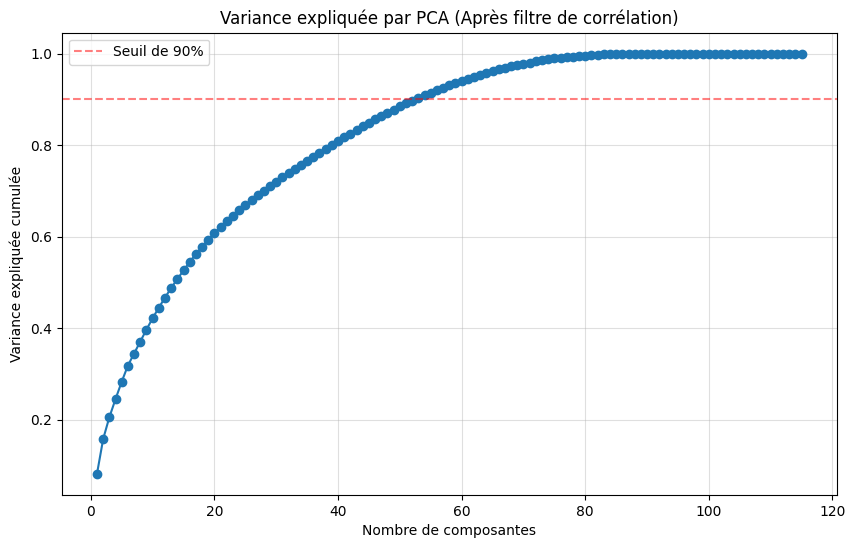

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# On s'assure qu'on a bien des splits
if len(splits) > 0:
    # 1. Récupération de X_train (en format DataFrame)
    train_idx, val_idx, test_idx, test_year = splits[0]
    X_train_df = df.loc[train_idx, features] 
    
    # ---------------------------------------------------------
    # 2. FILTRE DES CORRÉLATIONS
    # ---------------------------------------------------------
    threshold = 0.8
    col_corr = set()  # Ensemble des colonnes à supprimer
    corr_matrix = X_train_df.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    print(f"Features à supprimer (corrélation > {threshold}) :")
    print(col_corr)

    # DataFrame réduit
    #df_reduced = X_train_df.drop(columns=col_corr)
    #print(f"Dimensions avant PCA : {df_reduced.shape}")
    
    # ---------------------------------------------------------
    # 3. SCALING & PCA (Sur le DataFrame réduit !)
    # ---------------------------------------------------------
    # Centrage et Réduction
    scaler = StandardScaler()
    X_train_scale = scaler.fit_transform(X_train_df) 
    
    # Entraînement de la PCA
    pca = PCA()
    pca.fit(X_train_scale)

    # Calcul de la variance expliquée
    explained_var = pca.explained_variance_ratio_
    cumulative_var = np.cumsum(explained_var)

    # 4. Affichage du graphique
    plt.figure(figsize=(10, 6))
    # range(1, ...) permet d'avoir l'axe X qui commence à 1 composante (et pas 0)
    plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')
    plt.axhline(y=0.90, color='r', linestyle='--', alpha=0.5, label='Seuil de 90%') # Ligne visuelle
    plt.xlabel("Nombre de composantes")
    plt.ylabel("Variance expliquée cumulée")
    plt.title("Variance expliquée par PCA (Après filtre de corrélation)")
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()
    
else:
    print("Pas assez de données pour le split.")

## Matrix Correlation

In [10]:
threshold = 0.8
col_corr = set()  # Ensemble des colonnes à supprimer
corr_matrix = X_train_df.corr()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            colname = corr_matrix.columns[i]
            col_corr.add(colname)

print(f"Features à supprimer (corrélation > {threshold}) :")
print(col_corr)

# Supprimer les colonnes redondantes
df_reduced = X_train_df.drop(columns=col_corr)

Features à supprimer (corrélation > 0.8) :
{'netProfitMargin', 'bottomLineProfitMargin', 'priceToBookRatio', 'returnOnAssets', 'returnOnTangibleAssets', 'evToFreeCashFlow', 'quickRatio', 'continuousOperationsProfitMargin', 'evToOperatingCashFlow', 'assetTurnover', 'netIncomePerEBT', 'netDebtToEBITDA', 'operatingProfitMargin', 'pretaxProfitMargin', 'effectiveTaxRate', 'priceToFairValue', 'priceToOperatingCashFlowRatio', 'operatingCashFlowSalesRatio', 'enterpriseValue', 'forwardPriceToEarningsGrowthRatio', 'solvencyRatio', 'dividendYieldPercentage', 'priceToSalesRatio', 'daysOfInventoryOutstanding', 'freeCashFlowPerShare', 'enterpriseValueMultiple', 'priceToFreeCashFlowRatio', 'capexToOperatingCashFlow', 'evToSales', 'returnOnInvestedCapital', 'debtToAssetsRatio', 'ebitMargin', 'operatingCycle', 'debtToEquityRatio'}


## 3. Evaluation Metrics ($R^2_{OOS}$)

In [11]:
def calculate_r2_oos(y_true, y_pred):
    """
    Out-of-Sample R^2.
    Denominator uses 0 as the prediction benchmark (predicting exactly zero excess return).
    """
    numerator = np.sum((y_true - y_pred)**2)
    denominator = np.sum((y_true - 0)**2)
    return 1 - (numerator / denominator)


### Random Forest (GridSearchCV + MLflow Autolog)

In [12]:
def train_rf_cv(X_train, y_train):
    mlflow.sklearn.autolog()
    
    with mlflow.start_run(run_name="RF_GridSearch", nested=True):
        rf = RandomForestRegressor(random_state=42, n_jobs=-1)
        param_grid = {
            'n_estimators': [500, 700, 100],
            'max_depth': [3, 5, 6],
            'max_features': ['sqrt', 'log2']
        }
        
        # GridSearchCV for hyperparameter tuning
        grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        
        print(f"Best RF Params: {grid_search.best_params_}")
        return grid_search.best_estimator_


### Deep Neural Network (KerasTuner + MLflow Autolog + Ensembling)

In [13]:
def build_model(hp, input_dim):
    """KerasTuner model building function"""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    # Tune the number of units in the first Dense layer
    hp_units1 = hp.Int('units_1', min_value=16, max_value=64, step=16)
    model.add(layers.Dense(units=hp_units1, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Tune the number of units in the second Dense layer
    hp_units2 = hp.Int('units_2', min_value=8, max_value=32, step=8)
    model.add(layers.Dense(units=hp_units2, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Third hidden layer (fixed small)
    hp_units3 = hp.Int('units_3', min_value=4, max_value=8, step=2)
    model.add(layers.Dense(units=hp_units3, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Output layer
    model.add(layers.Dense(1))
    
    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='mse',
                  metrics=['mae'])
    return model

def train_dnn_ensemble(X_train, y_train, X_val, y_val, scaler, num_models=5, epochs=100, patience=5):
    mlflow.tensorflow.autolog(disable=True) 
    
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    input_dim = X_train_scaled.shape[1]
    
    # ==========================================
    # 🚀 THE MLOPS FIX: tf.data PIPELINE
    # ==========================================
    batch_size = 32768 # You can increase this to 512 or 1024 if VRAM allows
    
    # 1. Train Dataset: Shuffle, Batch, Cache, and Prefetch
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train.values))
    train_dataset = train_dataset.shuffle(buffer_size=len(X_train_scaled)) \
                                 .batch(batch_size) \
                                 .cache() \
                                 .prefetch(tf.data.AUTOTUNE)
                                 
    # 2. Validation Dataset: Batch, Cache, and Prefetch (No need to shuffle val data)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val_scaled, y_val.values))
    val_dataset = val_dataset.batch(batch_size) \
                             .cache() \
                             .prefetch(tf.data.AUTOTUNE)
    # ==========================================

    print("Starting KerasTuner RandomSearch...")
    with tf.device('/CPU:0'):
        tuner = kt.RandomSearch(
            lambda hp: build_model(hp, input_dim),
            objective='val_loss',
            max_trials=5,     
            directory='keras_tuner_dir',
            project_name='momentum_dnn',
            overwrite=True
        )
    
        early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
        
        # Pass the datasets instead of raw arrays. Drop the 'batch_size' arg since the dataset handles it.
        tuner.search(train_dataset, epochs=30, validation_data=val_dataset, callbacks=[early_stopping], verbose=0)
        best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
        print(f"Best HPs found: Layer1: {best_hps.get('units_1')}, Layer2: {best_hps.get('units_2')}, LR: {best_hps.get('learning_rate')}")
    
    models = []
    mlflow.tensorflow.autolog() 
    
    for i in range(num_models):
        with mlflow.start_run(run_name=f"DNN_Ensemble_Member_{i+1}", nested=True):
            mlflow.log_params(best_hps.values)
            tf.random.set_seed(42 + i)
            
            model = tuner.hypermodel.build(best_hps)
            
            # Use the pre-built tf.data pipeline for blazing fast training
            history = model.fit(
                train_dataset,
                epochs=epochs,
                validation_data=val_dataset,
                callbacks=[early_stopping],
                verbose=0
            )
            val_loss = min(history.history['val_loss'])
            print(f"Trained DNN component {i+1}/{num_models} - Best Val Loss: {val_loss:.6f}")
            models.append(model)
        
    return models

def predict_dnn_ensemble(models, scaler, X_test):
    X_test_scaled = scaler.transform(X_test)
    
    # Create a fast prediction pipeline
    test_dataset = tf.data.Dataset.from_tensor_slices(X_test_scaled)
    test_dataset = test_dataset.batch(32768).cache().prefetch(tf.data.AUTOTUNE)
    
    preds = []
    for model in models:
        # Pass the dataset to predict
        pred = model.predict(test_dataset, verbose=0).flatten()
        preds.append(pred)
        
    return np.mean(preds, axis=0)


## 5. Backtesting Portfolio Construction (Decile Sorting)

In [29]:
def backtest_portfolio(test_df, predictions_col, transaction_cost=0.001, decile=10):
    """
    Simulates a Long-Only (or Long/Short) portfolio with dynamic transaction costs.
    Applies fees ONLY to the stocks that are swapped in and out each week.
    """
    results = []
    
    # CRITICAL FIX 1: You MUST sort the dataframe before using shift(-1), 
    # otherwise you will mix up dates and different stock tickers!
    test_df = test_df.copy()
    test_df['date'] = pd.to_datetime(test_df['date'])
    test_df = test_df.sort_values(by=['symbol', 'date'])
    test_df['return+1'] = test_df.groupby('symbol')['adjClose'].shift(-1) / test_df['adjClose'] - 1
    
    # Initialize empty sets to track what we held the previous week
    prev_long_symbols = set()
    prev_short_symbols = set()

    for date, week_data in test_df.groupby('date'):
        if len(week_data) < 10: 
            continue
            
        week_data = week_data.copy()
        if 'dollar_volume' not in week_data.columns:
            week_data['dollar_volume'] = week_data['volume'] * week_data['adjClose']
            
        # --- 1. BENCHMARK CALCULATION ---
        universe_weights = week_data['dollar_volume'] / week_data['dollar_volume'].sum()
        benchmark_return = np.sum(universe_weights * week_data['return+1'])
        
        # --- 2. PORTFOLIO LONG / SHORT ---
        try:
            # Rank stocks into deciles based on your AI's predictions
            week_data['decile'] = pd.qcut(week_data[predictions_col], decile, labels=False, duplicates='drop') + 1
            max_decile = week_data['decile'].max()
            min_decile = week_data['decile'].min()
            
            long_portfolio = week_data[week_data['decile'] == max_decile]
            short_portfolio = week_data[week_data['decile'] == min_decile]
            
            curr_long_symbols = set(long_portfolio['symbol'])
            curr_short_symbols = set(short_portfolio['symbol'])
            
            num_l = len(curr_long_symbols)
            num_s = len(curr_short_symbols)
            
            if num_l > 0 and num_s > 0:
                # Calculate Gross Returns (Currently Equal-Weighted)
                ret_long = long_portfolio['return+1'].mean()
                ret_short = short_portfolio['return+1'].mean()
                
                # CRITICAL FIX 2: If you want a Long-Only fund, use ret_long.
                # If you want a market-neutral Long/Short fund, use (ret_long - ret_short) / 2
                gross_portfolio_return = ret_long # Assuming Long-Only for now
                
                # --- 3. DYNAMIC TRANSACTION COSTS (TURNOVER) ---
                # Find how many NEW stocks we are buying this week
                new_longs = curr_long_symbols - prev_long_symbols
                
                # Calculate Long Turnover: Fraction of the portfolio that is new
                # E.g., if we hold 50 stocks, and 5 are new, turnover is 10% (0.10)
                turnover_long = len(new_longs) / num_l if prev_long_symbols else 1.0 
                
                # We pay the fee to BUY the new stock, AND we pay the fee to SELL the old stock. 
                # Therefore, cost = turnover * transaction_cost * 2 trades
                cost_long = turnover_long * transaction_cost * 2
                
                # Net Return = Gross minus the dynamic costs
                net_portfolio_return = gross_portfolio_return - cost_long
                
                # Update our memory for the next week's loop
                prev_long_symbols = curr_long_symbols
                prev_short_symbols = curr_short_symbols
                
        except Exception as e:
            ret_long, ret_short, gross_portfolio_return, net_portfolio_return = 0, 0, 0, 0
            num_l, num_s = 0, 0
            
        results.append({
            'date': date,
            'ret_long': ret_long,
            'ret_short': ret_short,
            'gross_return': gross_portfolio_return,
            'portfolio_return': net_portfolio_return,
            'benchmark_return': benchmark_return,
            'turnover_pct': turnover_long, # Track this to see how much your AI trades!
            'num_long': num_l,
            'num_short': num_s
        })
            
    bt_df = pd.DataFrame(results)

    # --- METRICS CALCULATION (Same as your original code) ---
    if bt_df.empty:
        return bt_df, {}
        
    bt_df['date'] = pd.to_datetime(bt_df['date'])
    bt_df = bt_df.dropna(subset=['portfolio_return'])
    bt_df['cum_return'] = (1 + bt_df['portfolio_return']).cumprod()
    bt_df['cum_benchmark'] = (1 + bt_df['benchmark_return']).cumprod()
    bt_df['outperformance'] = bt_df['cum_return'] - bt_df['cum_benchmark']

    
    n_years = bt_df['date'].dt.year.nunique()
    
    total_ret = bt_df['cum_return'].iloc[-1] - 1
    cagr = (bt_df['cum_return'].iloc[-1]) ** (1 / max(1, n_years)) - 1
    mean_ret = bt_df['portfolio_return'].mean()
    std_ret = bt_df['portfolio_return'].std()
    
    sharpe = ((mean_ret / std_ret) * np.sqrt(52)) if std_ret > 0 else 0
    max_dd = ((bt_df['cum_return'] - bt_df['cum_return'].cummax()) / bt_df['cum_return'].cummax()).min()

    bench_total_ret = bt_df['cum_benchmark'].iloc[-1] - 1

    bench_cagr = (bt_df['cum_benchmark'].iloc[-1]) ** (1 / n_years) - 1 if n_years > 0 and bt_df['cum_benchmark'].iloc[-1] > 0 else 0
    bench_mean = bt_df['benchmark_return'].mean()
    bench_std = bt_df['benchmark_return'].std()
    bench_sharpe = (bench_mean / bench_std) * np.sqrt(52) if bench_std > 0 else 0
    bench_max_dd = ((bt_df['cum_benchmark'] - bt_df['cum_benchmark'].cummax()) / bt_df['cum_benchmark'].cummax()).min()
        
    metrics = {
        'Total_Return': total_ret,
        'CAGR': cagr,
        'Sharpe_Ratio': sharpe,
        'Max_Drawdown': max_dd,
        'Bench_Total_Return': bench_total_ret,
        'Bench_CAGR': bench_cagr,
        'Bench_Sharpe': bench_sharpe,
        'Bench_Max_Drawdown': bench_max_dd
    }
    
    return bt_df, metrics

## 6. Run the Pipeline over the Expanding Window

In [15]:
import mlflow
if len(splits) > 0:
    print(f"🚀 Lancement du Walk-Forward Backtest sur {len(splits)} années...")
    
    all_oos_results = []
    last_rf_model = None # Pour sauvegarder le modèle de la dernière année

    STRATEGY_FREQ = "weekly"
    TRANS_COST = 0.001
    DNN_EPOCHS = 100
    DNN_MODELS = 5
    TARGET_FREQ = "1 months"
    NUM_SPLITS = 1
    DECILE = 25
    NOTES = "Test avec une target de 3 mois et une fréquence hebdomadaire avec 1 split. Avec les features Momentum, Value et Profitable. Par contre, je n'ai pas fait de Reduction des features"

    mlflow.set_experiment("Long_Short_Short_SP500")
    
    run_name = f"Test_{STRATEGY_FREQ}_Cost{TRANS_COST}_DnnEp{DNN_EPOCHS}_DnnModels{DNN_MODELS}_Target{TARGET_FREQ}_Decile{DECILE}_Splits{NUM_SPLITS}_Notes{NOTES}"

    # On ouvre un seul grand Run MLflow pour tout le backtest
    with mlflow.start_run(run_name="Full_Walk_Forward_Backtest") as parent_run:

        mlflow.set_tag("Frequency", "Weekly")
        
        # 1. ENREGISTREMENT DES PARAMÈTRES GLOBAUX
        mlflow.log_params({
            "frequency": STRATEGY_FREQ,
            "features_count": len(features),
            "features_list": ", ".join(features),
            "transaction_cost": TRANS_COST,
            "dnn_epochs": DNN_EPOCHS,
            "dnn_num_models": DNN_MODELS,
            "target_freq": TARGET_FREQ,
            "decile": DECILE,
            "num_splits": NUM_SPLITS,
            "notes": NOTES
        })
        
        # 2. LA BOUCLE SUR TOUTES LES ANNÉES
        for i, (train_idx, val_idx, test_idx, test_year) in enumerate(splits):
            print(f"\n--- Traitement de l'Année de Test {test_year} ({i+1}/{len(splits)}) ---")
            
            X_train, y_train = df.loc[train_idx, features], df.loc[train_idx, 'target_y']
            X_val, y_val = df.loc[val_idx, features], df.loc[val_idx, 'target_y']
            X_test, y_test = df.loc[test_idx, features], df.loc[test_idx, 'target_y']
            
            # Setup scaler for DNN (réajusté chaque année)
            scaler = StandardScaler()
            scaler.fit(X_train)
            
            # Entraînement RF
            print("  -> Training RF...")
            rf_model = train_rf_cv(X_train, y_train)
            rf_preds = rf_model.predict(X_test)
            last_rf_model = rf_model # On le garde en mémoire pour extraire les features à la fin
            
            # Entraînement DNN
            print("  -> Training DNN Ensemble...")
            dnn_models = train_dnn_ensemble(X_train, y_train, X_val, y_val, scaler, num_models=DNN_MODELS, epochs=DNN_EPOCHS, patience=3)
            dnn_preds = predict_dnn_ensemble(dnn_models, scaler, X_test)
            
            # --- NOUVEAU : SUIVI ANNÉE PAR ANNÉE ---
            r2_rf_year = float(calculate_r2_oos(y_test.values, rf_preds))
            r2_dnn_year = float(calculate_r2_oos(y_test.values, dnn_preds))
            
            # On force le cast en int() pour le step !
            mlflow.log_metric("Yearly_RF_R2_OOS", r2_rf_year, step=int(test_year))
            mlflow.log_metric("Yearly_DNN_R2_OOS", r2_dnn_year, step=int(test_year))
            
            print(f"  -> RF R2 {test_year}: {r2_rf_year:.4f} | DNN R2 {test_year}: {r2_dnn_year:.4f}")
            
            # Stockage des prédictions pour cette année
            test_df_year = df.loc[test_idx].copy()
            test_df_year['rf_pred'] = rf_preds
            test_df_year['dnn_pred'] = dnn_preds
            
            all_oos_results.append(test_df_year)
            
        # =========================================================
        # 3. L'ASSEMBLAGE (Le vrai Backtest Global)
        # =========================================================
        print("\n" + "="*50)
        print("🔗 Assemblage des prédictions et calcul du Backtest Global...")
        
        final_test_df = pd.concat(all_oos_results).sort_values(['symbol', 'date'])
        
        # --- NOUVEAU : SAUVEGARDE DES PRÉDICTIONS BRUTES EN ARTEFACT ---
        print("💾 Sauvegarde des prédictions brutes dans MLflow...")
        csv_path = "final_predictions.csv"
        final_test_df.to_csv(csv_path, index=False)
        mlflow.log_artifact(csv_path)
        
        # Évaluation R^2 globale sur toute la période OOS
        r2_rf_global = calculate_r2_oos(final_test_df['target_y'].values, final_test_df['rf_pred'].values)
        r2_dnn_global = calculate_r2_oos(final_test_df['target_y'].values, final_test_df['dnn_pred'].values)
        
        mlflow.log_metric("Global_RF_R2_OOS", r2_rf_global)
        mlflow.log_metric("Global_DNN_R2_OOS", r2_dnn_global)
        
        # Passage au simulateur de portefeuille (ATTENTION AU UNPACKING ICI)
        print("Running Backtest for RF Strategy...")
        bt_rf, metrics_rf = backtest_portfolio(final_test_df, 'rf_pred', transaction_cost=TRANS_COST, decile=DECILE)
        
        print("Running Backtest for DNN Strategy...")
        bt_dnn, metrics_dnn = backtest_portfolio(final_test_df, 'dnn_pred', transaction_cost=TRANS_COST, decile=DECILE)
        
        # 4. AFFICHAGE ET SAUVEGARDE FINALE
        if not bt_rf.empty and not bt_dnn.empty:
            
            # Sauvegarde des métriques financières dans MLflow en forçant le type float()
            mlflow.log_metrics({f"RF_{k}": float(v) for k, v in metrics_rf.items()})
            mlflow.log_metrics({f"DNN_{k}": float(v) for k, v in metrics_dnn.items()})
            
            # Sauvegarde aussi les R2 globaux en forçant le float() (juste au cas où)
            mlflow.log_metric("Global_RF_R2_OOS", float(r2_rf_global))
            mlflow.log_metric("Global_DNN_R2_OOS", float(r2_dnn_global))
            
            # Formatage du joli tableau pour la console
            metrics_table = pd.DataFrame({
                "Métrique": ["Total Return", "CAGR (Annualisé)", "Sharpe Ratio", "Max Drawdown"],
                "Random Forest": [f"{metrics_rf['Total_Return']*100:.2f}%", f"{metrics_rf['CAGR']*100:.2f}%", f"{metrics_rf['Sharpe_Ratio']:.2f}", f"{metrics_rf['Max_Drawdown']*100:.2f}%"],
                "DNN Ensemble": [f"{metrics_dnn['Total_Return']*100:.2f}%", f"{metrics_dnn['CAGR']*100:.2f}%", f"{metrics_dnn['Sharpe_Ratio']:.2f}", f"{metrics_dnn['Max_Drawdown']*100:.2f}%"]
            })
            
            print("\n" + "="*55)
            print("📊 TABLEAU DES PERFORMANCES FINALES (AVEC FRAIS 0.1%)")
            print("="*55)
            print(metrics_table.to_string(index=False))
            print("="*55 + "\n")
            
            # Sauvegarde du tableau en format texte brut dans MLflow
            with open("performance_metrics.txt", "w") as f:
                f.write(metrics_table.to_string(index=False))
            mlflow.log_artifact("performance_metrics.txt")
            
            
            
            # --- NOUVEAU : GRAPHIQUE FEATURE IMPORTANCE ---
            if hasattr(last_rf_model, 'feature_importances_'):
                importances = last_rf_model.feature_importances_
                feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
                feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=True)
                
                plt.figure(figsize=(10, 6))
                plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color='skyblue')
                plt.title("RF Feature Importance (Dernière année de test)")
                plt.xlabel("Importance")
                
                feat_plot_path = "rf_feature_importance.png"
                plt.savefig(feat_plot_path, bbox_inches='tight')
                mlflow.log_artifact(feat_plot_path)
                plt.close() # Empêche ce graphique de s'afficher et de polluer ton écran
            
        else:
            print("Backtest yielded empty results (perhaps not enough data to form deciles).")
          
else:
    print("Not enough data to form a split. Check your timeframe.")


🚀 Lancement du Walk-Forward Backtest sur 1 années...

--- Traitement de l'Année de Test 2021 (1/1) ---
  -> Training RF...


2026/03/04 09:35:50 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/joblib/externals/loky/process_execu

Best RF Params: {'max_depth': 3, 'max_features': 'log2', 'n_estimators': 500}
  -> Training DNN Ensemble...


2026-03-04 09:49:54.376264: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-03-04 09:49:54.376696: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-03-04 09:49:54.376733: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
I0000 00:00:1772614194.377085   32732 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1772614194.377253   32732 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Starting KerasTuner RandomSearch...
Best HPs found: Layer1: 16, Layer2: 32, LR: 0.01


...

Trained DNN component 4/5 - Best Val Loss: 0.012180


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


2026/03/04 09:51:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/04 09:51:23 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during tensorflow autologging: 0.012179739773273468 is not in list


Trained DNN component 5/5 - Best Val Loss: 9.435964


  -> RF R2 2021: 0.0008 | DNN R2 2021: -7.4016

🔗 Assemblage des prédictions et calcul du Backtest Global...
💾 Sauvegarde des prédictions brutes dans MLflow...
Running Backtest for RF Strategy...
Running Backtest for DNN Strategy...

📊 TABLEAU DES PERFORMANCES FINALES (AVEC FRAIS 0.1%)
        Métrique Random Forest DNN Ensemble
    Total Return       132.74%      213.44%
CAGR (Annualisé)        15.12%       20.97%
    Sharpe Ratio          0.89         1.29
    Max Drawdown       -25.85%      -17.77%



## 7. Visualisation results

Running Backtest for RF Strategy...
Running Backtest for DNN Strategy...

📊 TABLEAU DES PERFORMANCES FINALES (HEBDOMADAIRE - AVEC FRAIS 0.1%)
        Métrique Random Forest DNN Ensemble
    Total Return       133.61%      259.50%
CAGR (Annualisé)        15.19%       23.77%
    Sharpe Ratio          0.79         1.12
    Max Drawdown       -32.61%      -36.21%



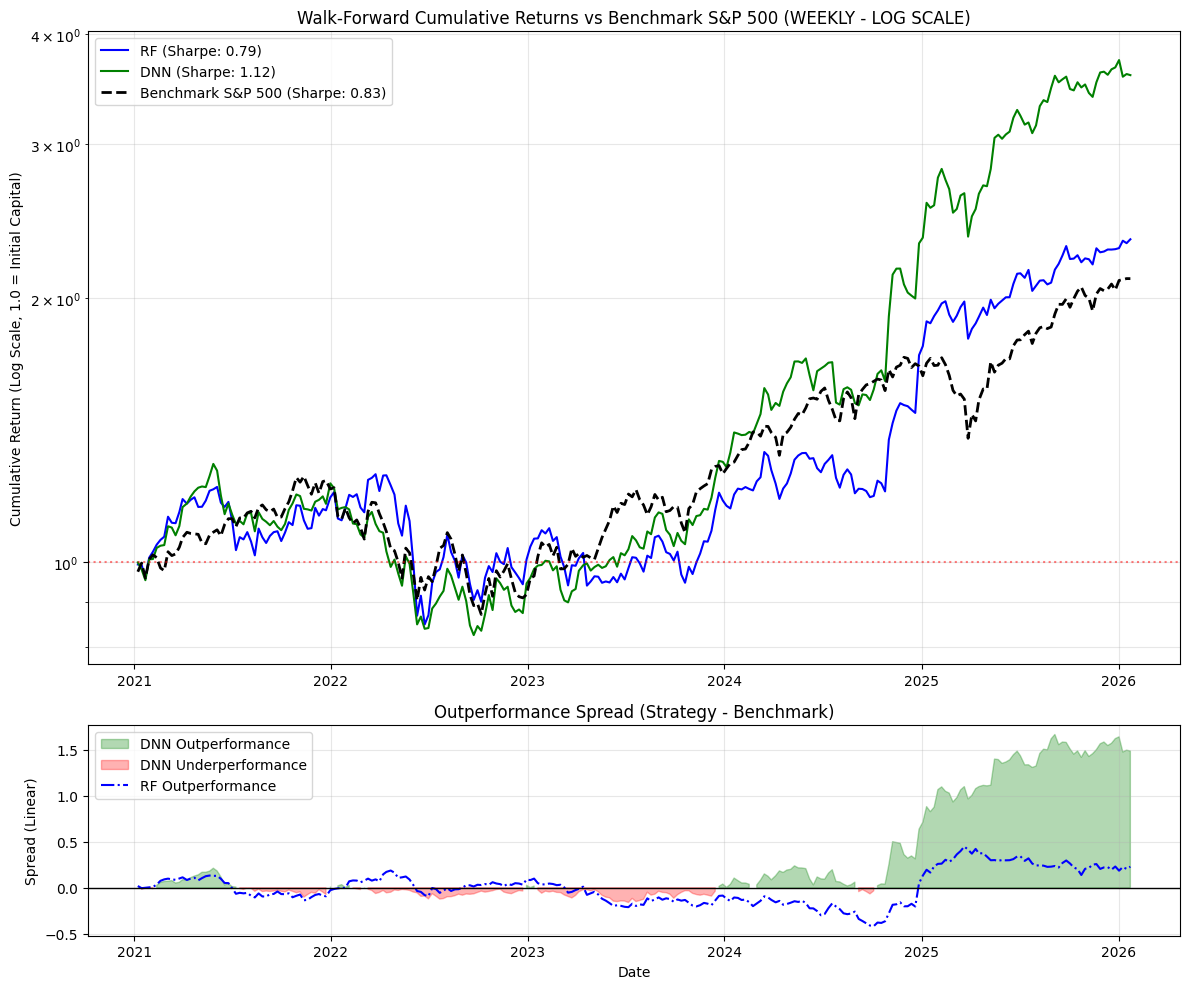

In [30]:
print("Running Backtest for RF Strategy...")
bt_rf, metrics_rf = backtest_portfolio(final_test_df, 'rf_pred', transaction_cost=0.001, decile=55)

print("Running Backtest for DNN Strategy...")
bt_dnn, metrics_dnn = backtest_portfolio(final_test_df, 'dnn_pred', transaction_cost=0.001, decile=55)

if not bt_rf.empty and not bt_dnn.empty:
    metrics_table = pd.DataFrame({
        "Métrique": ["Total Return", "CAGR (Annualisé)", "Sharpe Ratio", "Max Drawdown"],
        "Random Forest": [f"{metrics_rf['Total_Return']*100:.2f}%", f"{metrics_rf['CAGR']*100:.2f}%", f"{metrics_rf['Sharpe_Ratio']:.2f}", f"{metrics_rf['Max_Drawdown']*100:.2f}%"],
        "DNN Ensemble": [f"{metrics_dnn['Total_Return']*100:.2f}%", f"{metrics_dnn['CAGR']*100:.2f}%", f"{metrics_dnn['Sharpe_Ratio']:.2f}", f"{metrics_dnn['Max_Drawdown']*100:.2f}%"]
    })
    
    print("\n" + "="*55)
    print("📊 TABLEAU DES PERFORMANCES FINALES (HEBDOMADAIRE - AVEC FRAIS 0.1%)")
    print("="*55)
    print(metrics_table.to_string(index=False))
    print("="*55 + "\n")

# Graphique final avec Benchmark et Outperformance
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})
    
    ax1.plot(bt_rf['date'], bt_rf['cum_return'], label=f"RF (Sharpe: {metrics_rf['Sharpe_Ratio']:.2f})", color='blue')
    ax1.plot(bt_dnn['date'], bt_dnn['cum_return'], label=f"DNN (Sharpe: {metrics_dnn['Sharpe_Ratio']:.2f})", color='green')
    ax1.plot(bt_rf['date'], bt_rf['cum_benchmark'], label=f"Benchmark S&P 500 (Sharpe: {metrics_rf['Bench_Sharpe']:.2f})", color='black', linestyle='--', linewidth=2)
    
    ax1.axhline(y=1.0, color='red', linestyle=':', alpha=0.5)
    
    # --- NOUVEAU : Passage de l'axe Y en échelle logarithmique ---
    ax1.set_yscale('log')
    # -------------------------------------------------------------
    
    ax1.set_title('Walk-Forward Cumulative Returns vs Benchmark S&P 500 (WEEKLY - LOG SCALE)')
    ax1.set_ylabel('Cumulative Return (Log Scale, 1.0 = Initial Capital)')
    ax1.legend()
    ax1.grid(True, which="both", alpha=0.3) # "both" permet d'afficher la grille pour les sous-niveaux du log
    
    ax2.fill_between(bt_dnn['date'], bt_dnn['outperformance'], 0, where=(bt_dnn['outperformance'] >= 0), color='green', alpha=0.3, label='DNN Outperformance')
    ax2.fill_between(bt_dnn['date'], bt_dnn['outperformance'], 0, where=(bt_dnn['outperformance'] < 0), color='red', alpha=0.3, label='DNN Underperformance')
    ax2.plot(bt_rf['date'], bt_rf['outperformance'], color='blue', linestyle='-.', label='RF Outperformance')
    
    ax2.axhline(y=0.0, color='black', linewidth=1)
    ax2.set_title('Outperformance Spread (Strategy - Benchmark)')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Spread (Linear)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()

    plot_path = "global_cumulative_returns_vs_benchmark.png"
    plt.savefig(plot_path)
    mlflow.log_artifact(plot_path)
    
    plt.show()

In [17]:
final_test_df

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,year,month,week,target_y,rf_pred,dnn_pred,return+1
1074,A,2021-01-08,122.81,1577237,0.005492,0.000003,-0.776908,-0.146771,-0.291585,-0.377691,...,2.689046e+08,4.400000e+08,-1.339000e+09,2021,1,4,0.173995,0.031383,0.024348,-0.006677
1075,A,2021-01-15,121.99,2115400,-0.007190,0.000004,-0.839530,-0.518591,-0.549902,-0.624266,...,2.689046e+08,4.400000e+08,-1.339000e+09,2021,1,4,0.173995,0.031383,-0.080068,0.000984
1076,A,2021-01-22,122.11,1438728,-0.003011,0.000003,-0.582031,-0.417969,-0.425781,0.132812,...,2.689046e+08,4.400000e+08,-1.339000e+09,2021,1,4,0.173995,0.031383,-0.041301,-0.048808
1077,A,2021-01-29,116.15,1822000,-0.019312,0.000002,-0.005871,0.056751,0.005871,0.326810,...,2.689046e+08,4.400000e+08,-1.339000e+09,2021,1,4,0.173995,0.031383,0.013493,0.025054
1078,A,2021-02-05,119.06,1919710,0.003897,0.000001,-0.283757,-0.495108,-0.150685,0.424658,...,4.925385e+08,3.990000e+08,-1.387000e+09,2021,2,4,0.173995,0.031260,-0.025422,0.038972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
686739,ZTS,2025-11-28,127.64,2143000,0.005355,0.000154,0.608445,0.765835,-0.451056,0.358925,...,-1.459855e+09,1.594000e+09,-3.178000e+09,2025,11,4,0.024584,0.030642,0.050748,-0.074350
686740,ZTS,2025-12-05,118.15,4279887,0.001934,0.000147,-0.823755,-0.992337,-0.245211,-0.823755,...,-1.459855e+09,1.594000e+09,-3.178000e+09,2025,12,4,0.024584,0.030659,0.114390,0.000085
686741,ZTS,2025-12-12,118.16,5071179,-0.010664,0.000144,-0.080769,-0.044146,-0.474088,-0.365385,...,-1.459855e+09,1.594000e+09,-3.178000e+09,2025,12,4,0.024584,0.030671,0.047937,0.030129
686742,ZTS,2025-12-19,121.72,11297564,0.008818,0.000144,0.055662,0.443378,-0.631478,-0.071017,...,-1.459855e+09,1.594000e+09,-3.178000e+09,2025,12,4,0.024584,0.030642,0.046198,0.032616


In [18]:
final_test_df[final_test_df['date'] == '2023-01-06'].sort_values(by='dnn_pred', ascending=False).head(10)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,year,month,week,target_y,rf_pred,dnn_pred,return+1
288712,GS,2023-01-06,322.82,3097817,0.022841,0.000185,-0.817476,-0.860194,-0.867961,-0.557282,...,-1.570000e+09,1.088060e+11,-4.556290e+11,2023,1,4,-0.006448,0.025379,0.786507,0.074469
438972,MS,2023-01-06,78.67,5710900,0.022841,0.000185,-0.739806,-0.600000,-0.739806,-0.398058,...,-5.631600e+10,7.696100e+10,-5.326050e+11,2023,1,4,-0.018863,0.026889,0.495051,0.046905
261057,FNMA,2023-01-06,0.44,1971619,0.022841,0.000185,1.000000,1.000000,0.996117,-0.965049,...,-4.054000e+09,6.187700e+10,-4.172459e+12,2023,1,4,0.073171,0.084281,0.360103,-0.022727
100533,BRK-B,2023-01-06,318.69,3647900,0.022841,0.000185,-0.790291,-0.631068,-0.945631,-0.413592,...,2.894517e+09,3.730830e+11,-2.413400e+11,2023,1,4,0.104382,0.028406,0.346344,-0.003295
603526,TGT,2023-01-06,142.85,4944230,0.022841,0.000185,-0.526214,0.545631,-0.673786,-0.429126,...,-9.170902e+08,1.101900e+10,-2.420300e+10,2023,1,4,-0.198224,0.027094,0.342349,0.027791
390577,LOW,2023-01-06,188.55,3121509,0.022841,0.000185,-0.945631,-0.883495,-0.933981,-0.821359,...,-1.356326e+09,-1.286800e+10,-3.485000e+10,2023,1,4,0.134274,0.033633,0.338023,0.055635
239740,F,2023-01-06,9.80,53089146,0.022841,0.000185,-0.774757,-0.021359,-0.576699,-0.642718,...,-4.268019e+08,4.081700e+10,-9.624100e+10,2023,1,4,0.216683,0.030221,0.329501,0.011224
125898,CHTR,2023-01-06,367.73,1086000,0.022841,0.000185,-0.716505,0.460194,-0.580583,-0.840777,...,1.806015e+09,-8.714900e+10,-1.279570e+11,2023,1,4,0.027292,0.029398,0.305996,0.056400
69373,AZO,2023-01-06,2486.64,150272,0.022841,0.000185,-0.005825,0.013592,-0.506796,0.355340,...,8.108248e+08,-4.140568e+09,-1.252074e+10,2023,1,4,0.014324,0.035112,0.302465,-0.047357
279009,GM,2023-01-06,34.81,9783503,0.022841,0.000185,-0.782524,-0.219417,-0.495146,-0.495146,...,5.088938e+09,6.735000e+10,-9.130200e+10,2023,1,4,0.054153,0.030809,0.272270,0.016662


In [19]:
final_test_df[final_test_df['date'] == '2023-01-06'].sort_values(by='target_y', ascending=False).head(10)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,freeCashFlowToFirm,tangibleAssetValue,netCurrentAssetValue,year,month,week,target_y,rf_pred,dnn_pred,return+1
119947,CCL,2023-01-06,9.16,40099578,0.022841,0.000185,0.933981,0.984466,0.064078,-0.099029,...,-3.173839e+09,5.329000e+09,-3.714700e+10,2023,1,4,0.855446,0.065937,0.041532,0.141921
449655,NCLH,2023-01-06,13.04,14254338,0.022841,0.000185,0.770874,0.805825,0.460194,-0.374757,...,4.326084e+08,-5.300680e+08,-1.661623e+10,2023,1,4,0.618587,0.072592,0.041836,0.198620
534726,RCL,2023-01-06,54.04,3117928,0.022841,0.000185,0.895146,0.972816,0.456311,0.196117,...,-1.463746e+09,2.060000e+09,-2.770200e+10,2023,1,4,0.588749,0.049574,-0.004364,0.154330
473105,NVDA,2023-01-06,14.84,405044000,0.022841,0.000185,0.817476,0.654369,-0.980583,0.910680,...,4.105104e+09,1.512700e+10,4.084000e+09,2023,1,4,0.523243,0.046000,0.048420,0.137466
407278,MBC,2023-01-06,7.55,3381260,0.022841,0.000185,0.693204,-0.366990,0.972816,0.697087,...,1.580000e+08,-2.648000e+08,-6.902000e+08,2023,1,4,0.446517,0.036400,-0.036377,0.098013
279784,GNRC,2023-01-06,100.75,1394548,0.022841,0.000185,0.879612,0.693204,0.631068,0.860194,...,1.262823e+08,3.813200e+07,-6.173880e+08,2023,1,4,0.380705,0.030276,0.029336,0.128139
383813,LLY,2023-01-06,353.83,2131300,0.022841,0.000185,-0.852427,-0.902913,-0.918447,-0.537864,...,2.980441e+09,-5.042000e+08,-2.067990e+10,2023,1,4,0.369179,0.033684,0.115601,-0.003646
175974,DAL,2023-01-06,35.05,11110400,0.022841,0.000185,0.398058,0.844660,-0.219417,-0.603883,...,1.217162e+09,-9.176000e+09,-5.269500e+10,2023,1,4,0.361201,0.030416,-0.014040,0.060200
63025,AVGO,2023-01-06,56.25,35261010,0.022841,0.000185,0.724272,0.875728,-0.860194,0.856311,...,2.236728e+09,-2.801600e+10,-3.203600e+10,2023,1,4,0.359398,0.030744,0.009169,-0.016000
418823,META,2023-01-06,129.12,27584500,0.022841,0.000185,-0.324272,0.483495,-0.976699,-0.623301,...,1.280177e+09,1.045100e+11,-4.650000e+08,2023,1,4,0.354065,0.029367,0.251540,0.053516


In [20]:
df_test_decile = final_test_df.copy()

In [21]:
df_test_decile['decile'] = pd.qcut(df_test_decile['dnn_pred'], 65, labels=False, duplicates='drop') + 1
df_test_decile.describe()


,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,mom1w,...,tangibleAssetValue,netCurrentAssetValue,year,month,week,target_y,rf_pred,dnn_pred,return+1,decile
count,132835,132835.000000,1.328350e+05,132835.000000,132835.000000,132835.000000,132835.000000,132835.000000,132835.000000,132835.000000,...,1.328350e+05,1.328350e+05,132835.000000,132835.000000,132835.000000,132835.000000,132835.000000,132835.000000,132248.000000,132835.000000
mean,2023-07-07 11:25:22.198215936,171.190694,6.266723e+06,0.000769,0.000133,-0.002363,-0.001496,-0.004379,-0.001013,0.000346,...,7.702765e+09,-5.930827e+10,2023.010856,6.562487,3.973064,0.026366,0.034303,0.048591,0.002326,32.999977
min,2021-01-08 00:00:00,0.350000,6.347000e+03,-0.059746,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.146460e+11,-4.229289e+12,2021.000000,1.000000,3.000000,-0.976154,0.025379,-3.563846,-0.718322,1.000000
25%,2022-04-08 00:00:00,52.480000,1.030927e+06,-0.004750,0.000022,-0.500975,-0.500975,-0.502913,-0.500975,-0.500000,...,-2.448804e+09,-2.671582e+10,2022.000000,4.000000,4.000000,-0.069113,0.029987,-0.007534,-0.021174,17.000000
50%,2023-07-07 00:00:00,100.590000,2.181700e+06,0.001165,0.000172,-0.001949,-0.001942,-0.005825,-0.001912,0.000000,...,1.616600e+09,-8.437000e+09,2023.000000,7.000000,4.000000,0.021201,0.031253,0.040264,0.002431,33.000000
75%,2024-10-04 00:00:00,191.855000,5.064400e+06,0.007720,0.000210,0.496183,0.497143,0.493333,0.499044,0.500952,...,9.047500e+09,-2.329795e+09,2024.000000,10.000000,4.000000,0.116167,0.033727,0.089334,0.025187,49.000000
max,2025-12-26 00:00:00,9924.400000,1.142269e+09,0.030563,0.000223,1.000000,1.000000,1.000000,1.000000,1.000000,...,5.807980e+11,8.127400e+10,2025.000000,12.000000,4.000000,1.690763,1.774035,30.092825,0.795181,65.000000
std,NaN,368.131491,2.277304e+07,0.011350,0.000085,0.576955,0.577388,0.576521,0.577779,0.577781,...,3.831482e+10,2.927812e+11,1.415183,3.443093,0.161896,0.153435,0.028325,0.340284,0.044747,18.761871


In [22]:
max_decile = df_test_decile['decile'].max()
decile_long = df_test_decile[df_test_decile['decile'] == max_decile].sort_values(by='date', ascending=True)
decile_long_error = decile_long[decile_long['target_y'] < 0]
percent_false = len(decile_long_error)/len(decile_long)
percent_false

0.39187866927592957

In [23]:
min_decile = df_test_decile['decile'].min()
decile_short = df_test_decile[df_test_decile['decile'] == min_decile].sort_values(by='date', ascending=True)
decile_short_error = decile_short[decile_short['target_y'] > 0]
percent_false = len(decile_short_error)/len(decile_short)
percent_false

0.562133072407045

In [24]:
decile_long.sort_values(by='date', ascending=False).head(20)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,tangibleAssetValue,netCurrentAssetValue,year,month,week,target_y,rf_pred,dnn_pred,return+1,decile
680199,XOM,2025-12-26,118.32,8066129,-0.000301,0.000144,-0.034483,0.183908,-0.900383,0.609195,...,2.469140e+11,-9.761200e+10,2025,12,4,0.244760,0.030533,0.394265,NaN,65
441179,MSFT,2025-12-26,486.60,8842200,-0.000301,0.000144,-0.888889,-0.812261,-0.996169,-0.356322,...,2.223430e+11,-8.420900e+10,2025,12,4,-0.183662,0.030906,0.692920,NaN,65
478988,ODFL,2025-12-26,159.49,702500,-0.000301,0.000144,-0.160920,0.141762,-0.134100,0.137931,...,4.263196e+09,-5.896290e+08,2025,12,4,0.262712,0.030461,0.424142,NaN,65
595581,TDG,2025-12-26,1309.24,120655,-0.000301,0.000144,0.455939,0.727969,-0.203065,0.888889,...,-2.374500e+10,-2.557600e+10,2025,12,4,0.022715,0.034823,0.655204,NaN,65
100688,BRK-B,2025-12-26,498.30,2247600,-0.000301,0.000144,-0.191571,-0.049808,-0.934866,0.643678,...,5.807980e+11,-3.574300e+10,2025,12,4,-0.000201,0.030897,0.544713,NaN,65
261212,FNMA,2025-12-26,10.77,1306802,-0.000301,0.000144,0.919540,0.896552,0.969349,0.808429,...,1.054850e+11,-4.206315e+12,2025,12,4,-0.247911,0.035381,0.796027,NaN,65
473260,NVDA,2025-12-26,190.53,139740300,-0.000301,0.000144,0.758621,0.915709,-0.988506,0.436782,...,1.117000e+11,7.424100e+10,2025,12,4,-0.003726,0.037927,1.099463,NaN,65
93921,BKNG,2025-12-26,5440.14,69614,-0.000301,0.000144,-0.865900,-0.624521,-0.896552,-0.068966,...,-8.366000e+09,-1.178500e+10,2025,12,4,-0.250609,0.036467,0.498966,NaN,65
282512,GOOGL,2025-12-26,313.51,10899017,-0.000301,0.000144,0.072797,0.409962,-0.977011,0.532567,...,3.535980e+11,2.434500e+10,2025,12,4,0.004689,0.031419,0.542858,NaN,65
63180,AVGO,2025-12-26,352.13,15028133,-0.000301,0.000144,0.314176,0.804598,-0.969349,-0.053640,...,-4.878200e+10,-5.822700e+10,2025,12,4,-0.055320,0.030487,0.426043,NaN,65
